### Module 4 Homework: Linear Classification

#### Problem 1: Generating Data

Generate two 2D Gaussian clusters:

$
\mathbf{x}_0 \sim \mathcal{N}((0,0), I)
$

$
\mathbf{x}_1 \sim \mathcal{N}((\mu,0), I)
$

where $ I $ is the identity matrix.

1. Plot the generated data for $ \mu = 3 $.
2. Label each point by its class 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define function to generate two Gaussian clusters
def generate_two_gaussians(n_total=5000, mu=3, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    # split data into two classes
    n0 = n_total // 2
    n1 = n_total - n0

    # mean vectors 
    mu0 = np.array([0.0, 0.0])
    mu1 = np.array([mu, 0.0])
    cov = np.eye(2) # identity matrix

    X0 = rng.multivariate_normal(mu0, cov, size=n0)
    X1 = rng.multivariate_normal(mu1, cov, size=n1)

    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(n0), np.ones(n1)]).astype(int)

    idx = rng.permutation(len(y))
    return X[idx], y[idx], ['x1', 'x2']

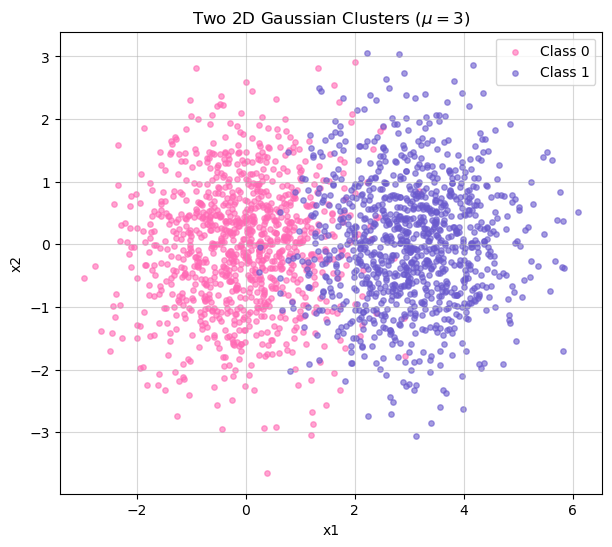

In [2]:
# Plot 2D Gaussian cluters
rng = np.random.default_rng(42)
X, y, feature_names = generate_two_gaussians(n_total=2000, mu=3.0, rng=rng)

plt.figure(figsize=(7, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=15, alpha=0.6, label='Class 0', color="hotpink")
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=15, alpha=0.6, label='Class 1', color = "slateblue")

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title(r'Two 2D Gaussian Clusters ($\mu = 3$)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

#### Problem 2: Linear Classifier

Using sklearn.linear_model.LogisticRegression:

1. Fit a classifier to the data
2. Plot the decision boundary
3. Shade the predicted probability regions


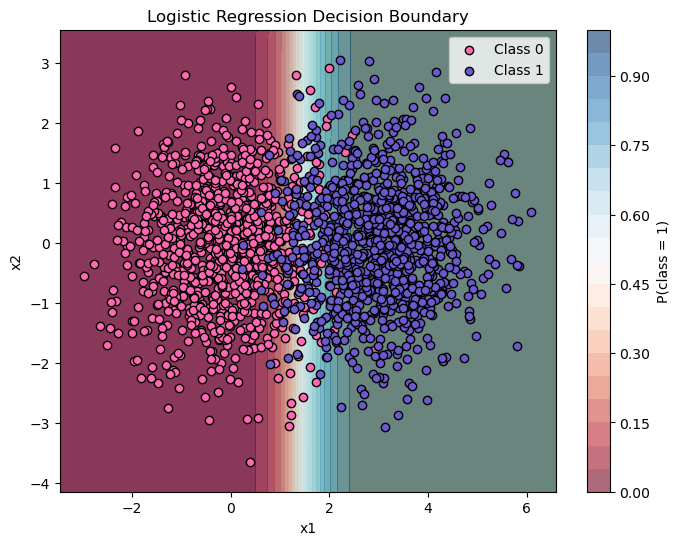

In [3]:
from sklearn.linear_model import LogisticRegression

# 1. Fit classifier to the data
clf = LogisticRegression()
clf.fit(X, y)

# 2. Plot the decision boundary
def plot_decision_boundary(clf, X, y):

    fig, ax = plt.subplots(figsize=(8,6))

    # create mesh
    margin = 0.5
    x_min, x_max = X[:,0].min() - margin, X[:,0].max() + margin
    y_min, y_max = X[:,1].min() - margin, X[:,1].max() + margin

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    # probabilities on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
    Z = Z.reshape(xx.shape)

    # 3. Shade predicted probability regions
    ax.contourf(xx, yy, Z, levels=20, alpha=0.5)

    # decision boundary
    contour = ax.contourf(xx, yy, Z, levels=20, alpha=0.6, cmap='RdBu')
    plt.colorbar(contour, ax=ax, label="P(class = 1)")
    
    # plot data
    ax.scatter(X[y==0,0], X[y==0,1], label='Class 0', edgecolor='k', color = "hotpink")
    ax.scatter(X[y==1,0], X[y==1,1], label='Class 1', edgecolor='k', color = "slateblue")

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title("Logistic Regression Decision Boundary")
    ax.legend()

    plt.show()

plot_decision_boundary(clf, X, y)

$\textbf{Problem 3}$

$\mu$ = 3.0, Accuracy = 0.9325, FPR = 0.066 and FNR = 0.069

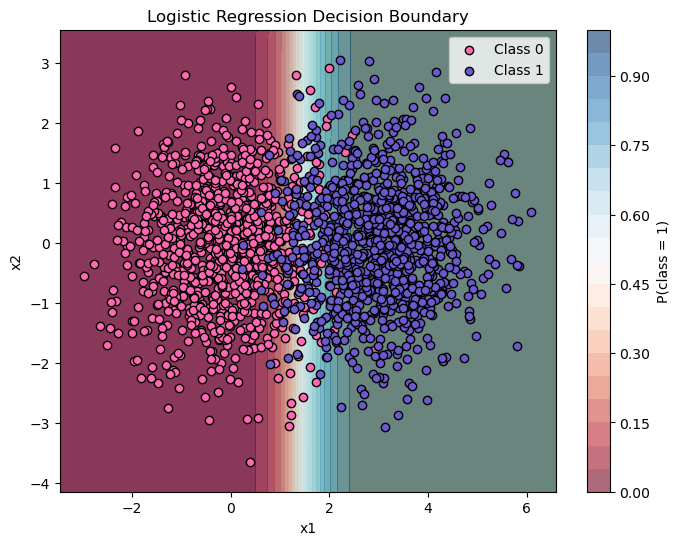

$\mu$ = 2.0, Accuracy = 0.8545, FPR = 0.145 and FNR = 0.146

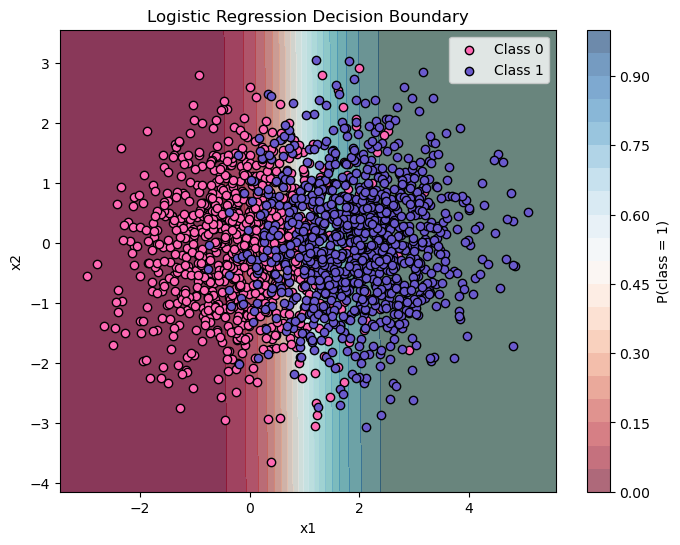

$\mu$ = 1.0, Accuracy = 0.7145, FPR = 0.277 and FNR = 0.294

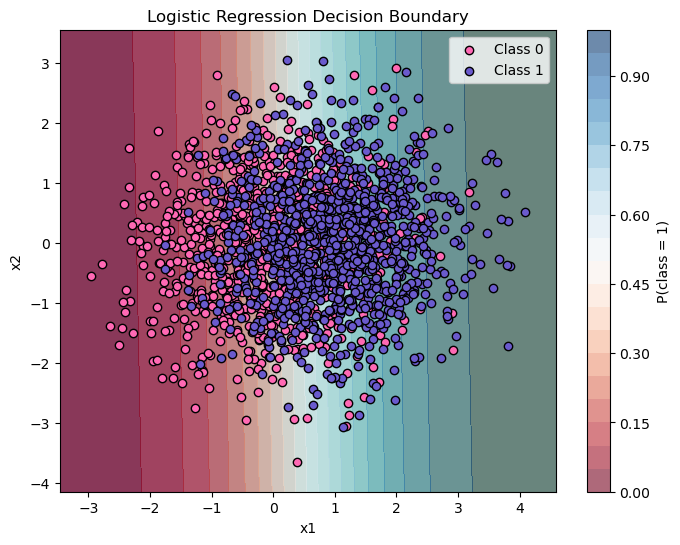

$\mu$ = 0.5, Accuracy = 0.6145, FPR = 0.388 and FNR = 0.383

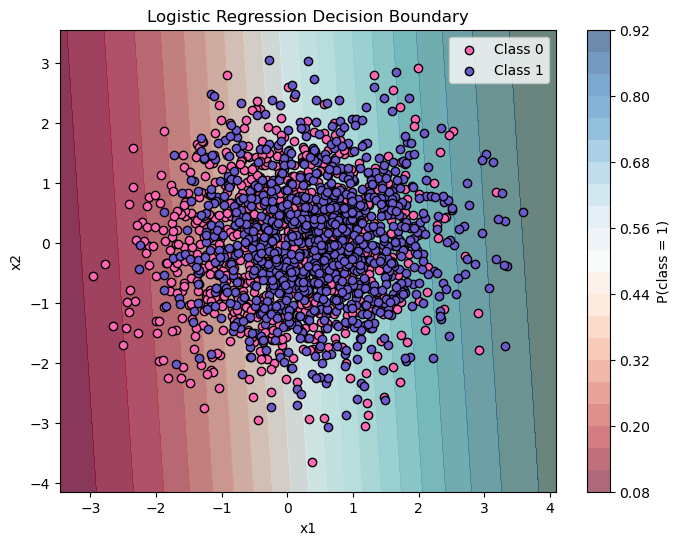

In [74]:
mu_values = [3.0, 2.0, 1.0, 0.5] #,0] this is for 4 part 2. 
from sklearn.metrics import accuracy_score
from IPython.display import display, Markdown

accuracies = []
for mu in mu_values:
    rng = np.random.default_rng(42)
    X, y, feature_names = generate_two_gaussians(n_total=2000, mu=mu, rng=rng) #n_total = 10000 for 4 part 2
    clf = LogisticRegression()
    clf.fit(X, y)
    predictions = clf.predict(X)
    
    accuracy = accuracy_score(y, predictions)
    accuracies.append(accuracy)
    
    false_positives = (predictions == 1) & (y == 0)
    n_fp = np.sum(false_positives)  
    
    false_negatives = (predictions == 0) & (y == 1)
    n_fn = np.sum(false_negatives) 
    
    true_negatives = (predictions == 0) & (y == 0)
    n_tn = np.sum(true_negatives)
    
    true_positives = (predictions == 1) & (y == 1)
    n_tp = np.sum(true_positives)
    
    FPR = n_fp/(n_fp+n_tn)
    FNR = n_fn/(n_tp+n_fn)
    
    display(Markdown(
    rf"""$\mu$ = {mu}, Accuracy = {accuracy}, FPR = {FPR} and FNR = {FNR}"""))
    plot_decision_boundary(clf, X, y)

Text(0.5, 1.0, 'Accuracy vs $\\mu$')

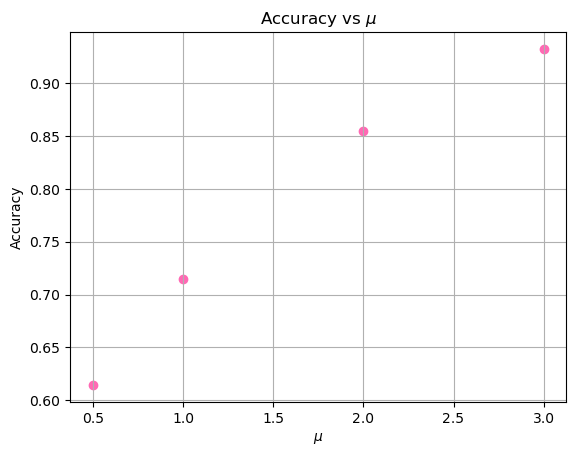

In [70]:
plt.scatter(mu_values, accuracies, color='hotpink')
plt.xlabel(r"$\mu$")
plt.ylabel('Accuracy')
plt.grid()
plt.title(r"Accuracy vs $\mu$")

$\textbf{Problem 4}$

Answer briefly:
1. Why does performance degrade as µ → 0? $\newline$
Just by looking at the visual trend we can tell that the performance degrades because the two classes start to overlap to a much greater extent as the mean is reduced. This overlap means that the two classes are no longer disparate and are quite close to being the same distribution.  
$\newline$
2. Does adding more data help when µ = 0? $\newline$
Adding more data points does not help when µ = 0 because the classes are identically distributed and adding more data will not change that. They will have the same mean and the same covariance. 
$\newline$
3. What assumption does a linear classifier make about the data? $\newline$
That the classes can be separated by a straight line in 2D or hyperplane in higher dimensions. It assumes the decision boundary is linear.